In [2]:
import os.path as osp
import sys
sys.path.append('../..')
import torch
from torch.utils.data import DataLoader

import numpy as np

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import qdre
import Camel.equations as equations

from qdre.plotting import get_r_hats
from evaluation_helpers import plot_closure

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#DEVICE = 'cpu'
print(DEVICE)

cuda:0


In [2]:
SAVE_DIR = "./models"
DATA_DIR = "./data"

In [3]:
source_mixture_coef = (4, -1)
source_scales = (2.5, 2.3)
target_mixture_coef = (2, -1)
target_scales = (2, 1.2)

source_file = osp.join(DATA_DIR, "base_distribution_mc_data")
target_file = osp.join(DATA_DIR, "target_distribution_mc_data")


STOP_EVENT = int(np.min((np.load(source_file + "_test.npy").shape[0], np.load(target_file + "_test.npy").shape[0])))
test_base_dataset = qdre.preprocessing.Dataset(source_file + "_test.npy", 0, stop_event=STOP_EVENT)
test_target_dataset = qdre.preprocessing.Dataset(target_file + "_test.npy", 1, stop_event=STOP_EVENT)

test_base_dataset.process(normalize_weights=True)
test_target_dataset.process(normalize_weights=True)

test_generator_data = qdre.preprocessing.CombinedDataset(test_base_dataset, test_target_dataset)
print(len(test_generator_data))

test_loader = DataLoader(test_generator_data, batch_size=int(2**10), shuffle=False)
test_nominal_loader = DataLoader(qdre.preprocessing.CombinedDataset(test_base_dataset), batch_size=int(2**10), shuffle=False)
test_target_loader = DataLoader(qdre.preprocessing.CombinedDataset(test_target_dataset), batch_size=int(2**10), shuffle=False)

2800000


In [4]:
# Get the analytical optimal classifier
s_optimal = equations.optimal_binary_classifier(source_mixture_coef, source_scales, target_mixture_coef, target_scales)

# Load the best models

## Load the SMM model

In [5]:
batch_size = int(2**8)
modpath = osp.join(SAVE_DIR, "classifier_SMM_batch{}.zip".format(batch_size))
SMM_model = qdre.models.load_model(modpath, device=DEVICE).to(DEVICE)
X_scaler_SMM, weight_norm_SMM = qdre.preprocessing.load_scaling(modpath)
SMM_model.coefficients

(1.3322486877441406, 1.995090126991272)

In [6]:
print(SMM_model)

MixtureClassifier(
  (subclassifiers): ModuleList(
    (0-3): 4 x Classifier(
      (model): Sequential(
        (0): Linear(in_features=2, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=32, bias=True)
        (3): ReLU()
        (4): Linear(in_features=32, out_features=1, bias=True)
        (5): Sigmoid()
      )
    )
  )
)


## Load the $\textrm{SMM}_c$ model

In [7]:
batch_size = int(2**8)
modpath = osp.join(SAVE_DIR, "classifier_SMMc_revert_batch{}.zip".format(batch_size))
SMMc_model = qdre.models.load_model(modpath, device=DEVICE).to(DEVICE)
X_scaler_SMMc, weight_norm_SMMc = qdre.preprocessing.load_scaling(modpath)
SMMc_model.coefficients

(1.1055060625076294, 1.9824146032333374)

In [8]:
print(SMMc_model)

MixtureClassifier(
  (subclassifiers): ModuleList(
    (0-3): 4 x Classifier(
      (model): Sequential(
        (0): Linear(in_features=2, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=32, bias=True)
        (3): ReLU()
        (4): Linear(in_features=32, out_features=1, bias=True)
        (5): Sigmoid()
      )
    )
  )
)


## Load the $\textrm{SMM}_r$ model

In [9]:
batch_size = int(2**8)
modpath = osp.join(SAVE_DIR, "classifier_SMMr_revert_batch{}.zip".format(batch_size))
SMMr_model = qdre.models.load_model(modpath, device=DEVICE).to(DEVICE)
X_scaler_SMMr, weight_norm_SMMr = qdre.preprocessing.load_scaling(modpath)
SMMr_model.coefficients

(1.270193338394165, 1.9948434829711914)

In [10]:
print(SMMr_model)

MixtureClassifier(
  (subclassifiers): ModuleList(
    (0-3): 4 x Classifier(
      (model): Sequential(
        (0): Linear(in_features=2, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=32, bias=True)
        (3): ReLU()
        (4): Linear(in_features=32, out_features=1, bias=True)
        (5): Sigmoid()
      )
    )
  )
)


## Load the REVERT classifier

In [11]:
LOSS = "revert"
batch_size = int(2**8)
modpath = osp.join(SAVE_DIR, "classifier_{}_batch{}.zip".format(LOSS, batch_size))
revert_model = qdre.models.load_model(modpath, device=DEVICE).to(DEVICE)
X_scaler_revert, weight_norm_revert = qdre.preprocessing.load_scaling(modpath)

In [12]:
print(revert_model)

Classifier(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


# Evaluate the models

## Look at reweighting closure metrics

In [13]:
model_names = ["MLP REVERT", "RoSMM", "RoSMM-c REVERT", "RoSMM-r REVERT", "Optimal"]
models = [revert_model, SMM_model, SMMc_model, SMMr_model, s_optimal]
X_scalers = [X_scaler_revert, X_scaler_SMM, X_scaler_SMMc, X_scaler_SMMr, None]
weight_norms = [weight_norm_revert, weight_norm_SMM, weight_norm_SMMc, weight_norm_SMMr, 1.0]

In [14]:
r_hats_list = []
for i in range(len(models)):
    loss = "revert" if "REVERT" in model_names[i] else "pare" if "PARE" in model_names[i] else "bce"
    mix = True if "SMM" in model_names[i] else False
    r_hat = get_r_hats(
        models[i],
        test_nominal_loader,
        X_scaler=X_scalers[i],
        weight_norm=weight_norms[i],
        loss=loss,
        mix=mix,
        leave=True,
        device=DEVICE
    )
    r_hats_list.append(r_hat)

100%|██████████| 1368/1368 [00:06<00:00, 214.90it/s]


/home/mdrnevich/test/QuasiDRE/ToyModels/../qdre/plotting.py:450: RuntimeWarning: divide by zero encountered in divide
  x1_ratio = x0_hist/x1_hist
/home/mdrnevich/test/QuasiDRE/ToyModels/../qdre/plotting.py:454: RuntimeWarning: divide by zero encountered in divide
  carl_ratio = [carl_hist[0]/x1_hist for carl_hist in carl_hists]
/home/mdrnevich/test/QuasiDRE/ToyModels/../qdre/plotting.py:496: RuntimeWarning: invalid value encountered in scalar divide
  binsqrsum_x1 = binsqrsum_x1/w1[mask1].sum()


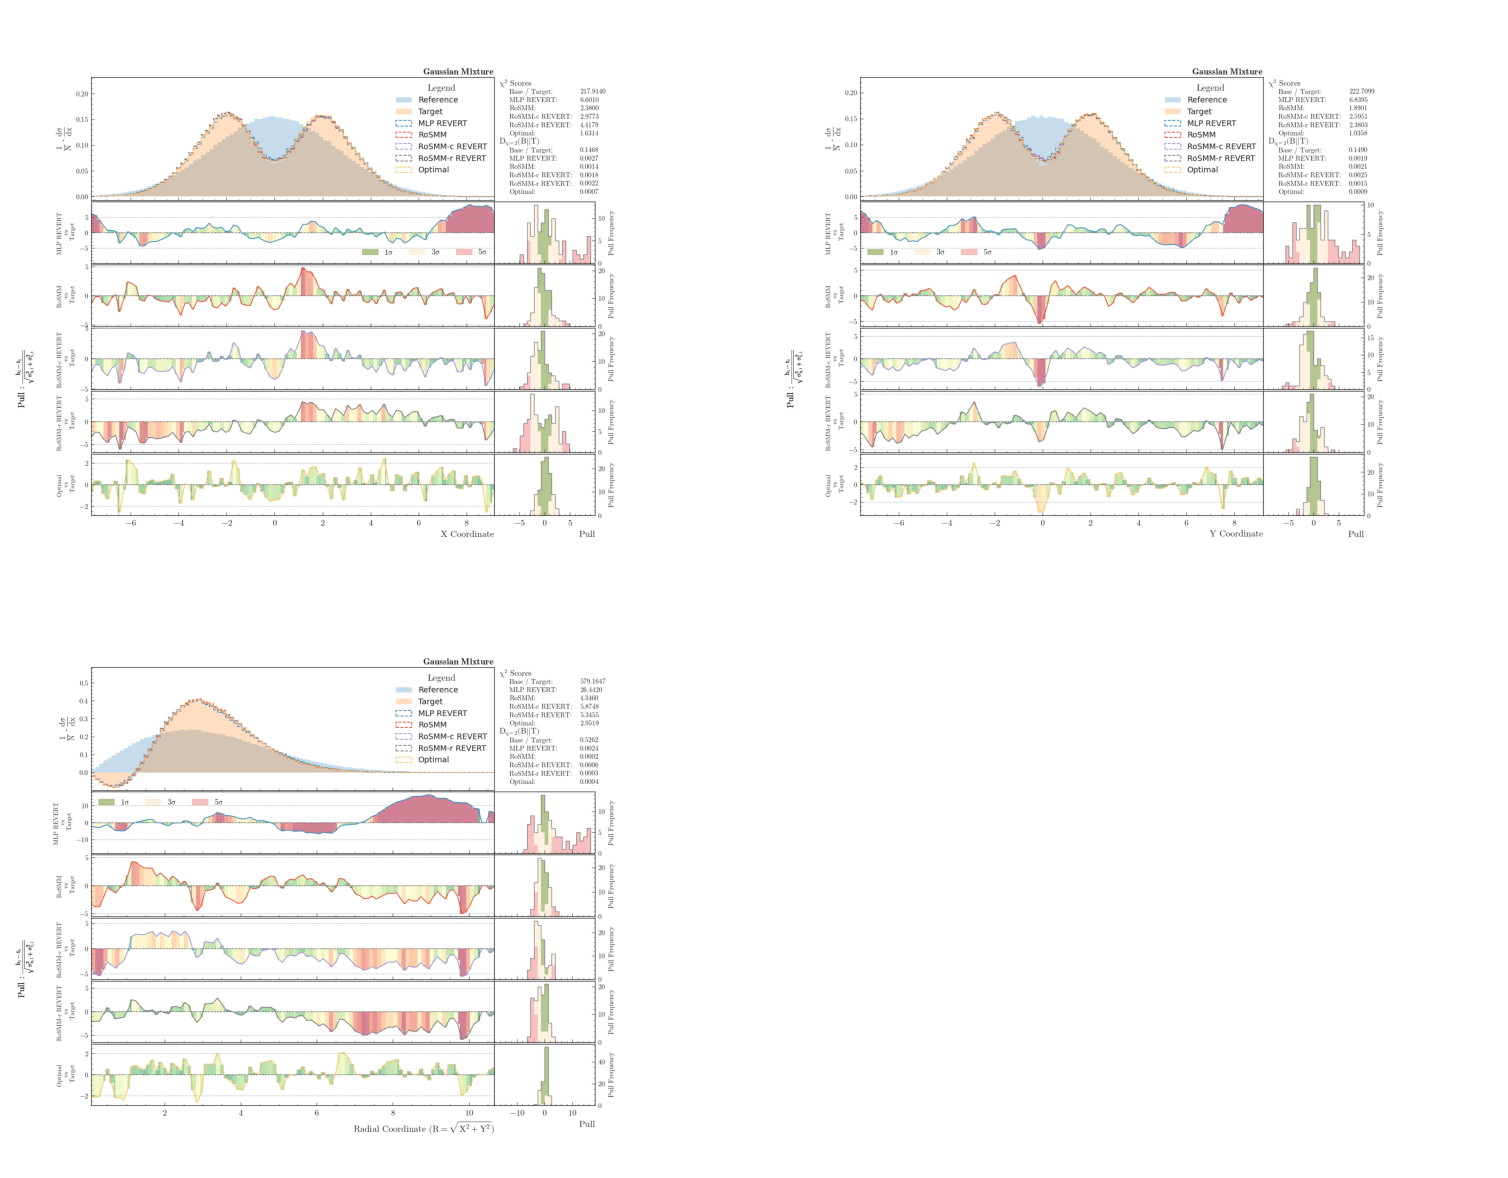

['/tmp/tmpt99smc8s/ToyModel_subdensity_0_tmp.png',
 '/tmp/tmpt99smc8s/ToyModel_subdensity_1_tmp.png',
 '/tmp/tmpt99smc8s/ToyModel_subdensity_2_tmp.png']

In [15]:
kwargs={'legend.title_fontsize': 16, 'legend.fontsize': 14, 'table.fontsize': 12,
        'font.size': 14, 'axes.titlesize':20, 'axes.labelsize':16,'figure.titlesize':20, 'ytick.labelsize':12, 'figure.figsize':(16,14)}

plot_closure(r_hats_list, test_nominal_loader, test_target_loader, "Reference", "Target", carl_names=model_names, percentile_cuts=(0.1, 99.99), kwargs_plot=kwargs)